<a href="https://colab.research.google.com/github/DienAkbar25/DesainAnalisisAlgoritma/blob/Lolo/DAA(TRIP_PLANNER).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
from itertools import combinations
import time, gc, statistics, random


In [4]:
places = {
    1: "Malioboro",
    2: "Tugu Jogja",
    3: "Alun-Alun Kidul",
    4: "Keraton Yogyakarta",
    5: "Taman Sari",
    6: "Museum Sonobudoyo",
    7: "Candi Prambanan",
    8: "Ratu Boko",
    9: "Tebing Breksi",
    10: "Kaliurang",
    11: "Basecamp Lava Tour Merapi",
    12: "Museum Ullen Sentalu",
    13: "Pantai Parang Teritis",
    14: "HeHa Sky View",
    15: "Hutam Pinus Pengger",
}

In [5]:
day = {
    1: 1, 2: 1, 3: 1,
    4: 2, 5: 2, 6: 2,
    7: 3, 8: 3, 9: 3,
    10: 4, 11: 4, 12: 4,
    13: 5, 14: 5, 15: 5
}

N = len(places)

In [6]:
order_by_day = {d: sorted([n for n,t in day.items() if t==d]) for d in sorted(set(day.values()))}

linear_graph = {n: [] for n in places.keys()}
days_sorted = sorted(order_by_day.keys())
for i, d in enumerate(days_sorted):
    seq = order_by_day[d]
    # chain inside day
    for j in range(len(seq)-1):
        linear_graph[seq[j]].append((seq[j+1], 1))
    # connect last of day to first of next day
    if i < len(days_sorted)-1:
        linear_graph[seq[-1]].append((order_by_day[days_sorted[i+1]][0], 1))

print("Linear adjacency list (debug):")
for u in sorted(linear_graph.keys()):
    print(f"{u:2d} -> {linear_graph[u]}")
print()

Linear adjacency list (debug):
 1 -> [(2, 1)]
 2 -> [(3, 1)]
 3 -> [(4, 1)]
 4 -> [(5, 1)]
 5 -> [(6, 1)]
 6 -> [(7, 1)]
 7 -> [(8, 1)]
 8 -> [(9, 1)]
 9 -> [(10, 1)]
10 -> [(11, 1)]
11 -> [(12, 1)]
12 -> [(13, 1)]
13 -> [(14, 1)]
14 -> [(15, 1)]
15 -> []



In [27]:
def topo_kahn(adj):
    indeg = {n:0 for n in adj}
    for u, edges in adj.items():
        for v,w in edges:
            indeg[v] += 1
    dq = deque([n for n in sorted(indeg.keys()) if indeg[n] == 0])
    out = []
    while dq:
        u = dq.popleft()
        out.append(u)
        for v,w in adj[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    return out


In [26]:
def topo_dfs(adj, day_map=None):
    visited = {n: False for n in adj}
    stack = []
    def dfs(u):
        visited[u] = True
        for v, w in sorted(adj.get(u, []), key=lambda x: x[0]):
            if not visited[v]:
                dfs(v)
        stack.append(u)
    if day_map is not None:
        start_nodes = sorted(adj.keys(), key=lambda x: (day_map.get(x, 0), x))
    else:
        start_nodes = sorted(adj.keys())
    for n in start_nodes:
        if not visited[n]:
            dfs(n)

    stack.reverse()
    return stack

In [9]:
def time_func(func, *args, reps=30):
    t0 = time.perf_counter()
    for _ in range(reps):
        func(*args)
    t1 = time.perf_counter()
    return (t1 - t0) / reps * 1000.0  # ms

order_kahn = topo_kahn(linear_graph)
order_dfs  = topo_dfs(linear_graph, day)

time_kahn = time_func(topo_kahn, linear_graph, reps=50)
time_dfs  = time_func(topo_dfs, linear_graph, day, reps=50)


In [10]:
def kendall_stability(a, b):
    assert set(a) == set(b)
    pos_b = {v:i for i,v in enumerate(b)}
    n = len(a)
    discord = 0
    total = 0
    for i,j in combinations(range(n), 2):
        u = a[i]; v = a[j]
        if pos_b[u] > pos_b[v]:
            discord += 1
        total += 1
    return 1.0 - (discord / total)

stability = kendall_stability(order_kahn, order_dfs)


In [11]:
def pos_per_day(order_by_day, x_step=3.0, y_step=2.0):
    pos = {}
    maxlen = max(len(v) for v in order_by_day.values())
    for i, d in enumerate(sorted(order_by_day.keys())):
        seq = order_by_day[d]
        x = i * x_step
        mid = (maxlen - 1) / 2
        for j, node in enumerate(seq):
            y = (mid - j) * y_step
            pos[node] = (x, y)
    return pos

def pos_from_order(order, x_step=1.5, y_level=0):
    pos = {}
    for i, node in enumerate(order):
        pos[node] = (i * x_step, y_level)
    return pos

def pos_day_topo(order, day_map, x_step=3.0, y_step=0.7):
    pos = {}
    rank = {n:i for i,n in enumerate(order)}
    for node in order:
        d = day_map[node]
        x = (d-1) * x_step
        y = -rank[node] * y_step
        pos[node] = (x, y)
    return pos

# build positions
pos_day = pos_per_day(order_by_day)
pos_kahn_topo = pos_from_order(order_kahn, x_step=1.2)
pos_dfs_topo  = pos_from_order(order_dfs, x_step=1.2)
pos_day_kahn_topo = pos_day_topo(order_kahn, day)
pos_day_dfs_topo = pos_day_topo(order_dfs, day)

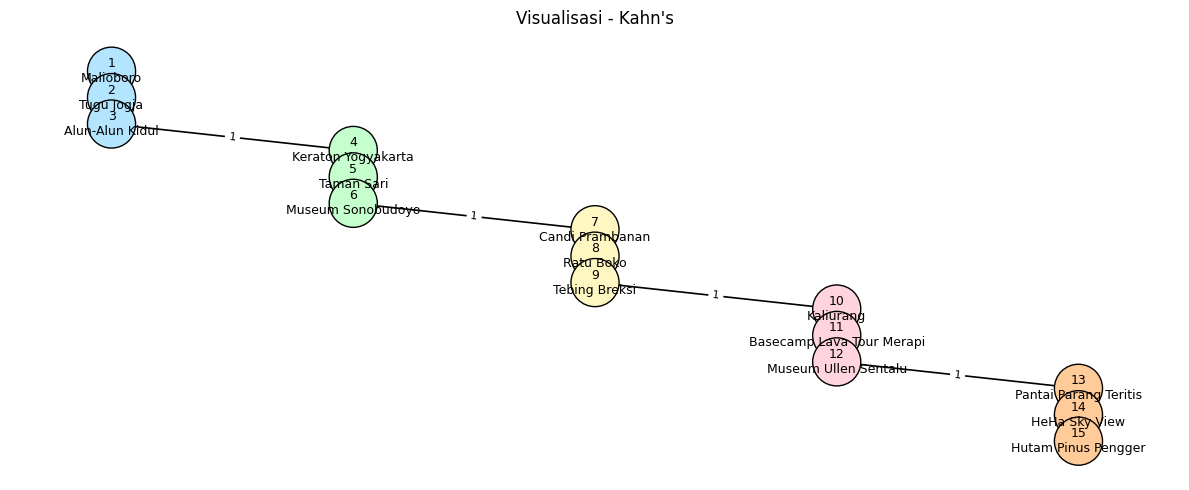

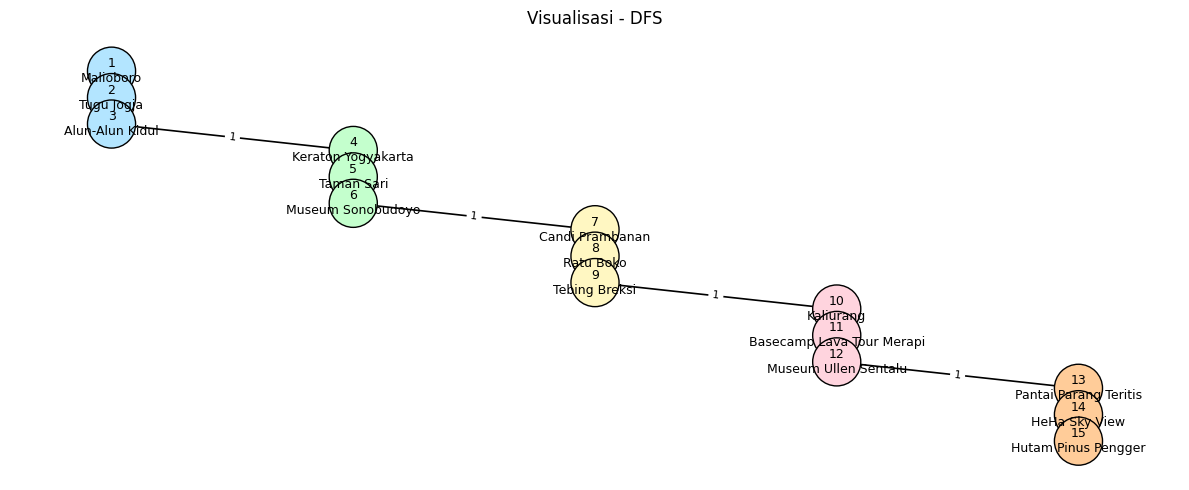

In [12]:
colors = {
    1:"#b3e5ff",
    2:"#c4ffcd",
    3:"#fff7c2",
    4:"#ffd4de",
    5:"#ffcc99"
}

def draw_graph(adj, pos, order=None, title=""):
    G = nx.DiGraph()
    for u, edges in adj.items():
        for v,w in edges:
            G.add_edge(u, v, weight=w)
    node_colors = [colors[day[n]] for n in G.nodes()]
    plt.figure(figsize=(12,5))
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, edgecolors='k')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=14, width=1.2)
    # edge labels
    edge_labels = {(u,v): G[u][v]['weight'] for u,v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    # labels: show rank if available
    if order is not None:
        rank = {n:i+1 for i,n in enumerate(order)}
        labels = {n: f"{rank[n]}\n{places[n]}" for n in G.nodes()}
    else:
        labels = {n: places[n] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_graph(linear_graph, pos_day_kahn_topo, order=order_kahn, title="Visualisasi - Kahn's")
draw_graph(linear_graph, pos_day_dfs_topo,  order=order_dfs,  title="Visualisasi - DFS")

=== GRAPH BENCHMARK (n=15) ===
Kahn  : mean=0.008417 ms  median=0.008087 ms  stdev=0.002094 ms  min=0.007921 ms  max=0.039056 ms
DFS   : mean=0.013293 ms  median=0.012703 ms  stdev=0.003611 ms  min=0.012122 ms  max=0.076249 ms



/tmp/ipython-input-1900982009.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([times_kahn, times_dfs], labels=["Kahn", "DFS"], showfliers=False)


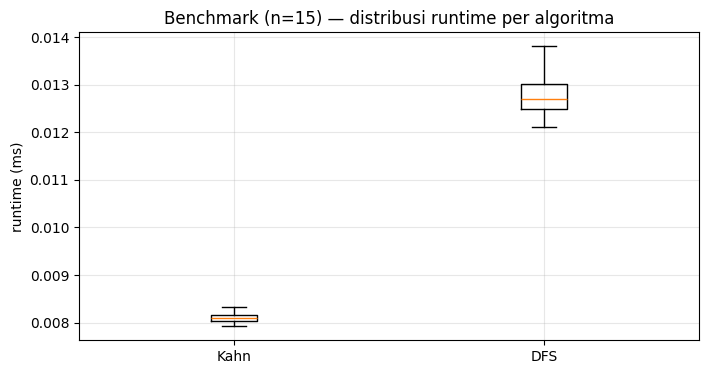

In [30]:
def bench(func, *args, reps=200):
    """Return list of runtimes in ms for `reps` runs (single-call timings)."""
    times = []
    for _ in range(20):
        func(*args)
    gc_old = gc.isenabled()
    gc.disable()
    try:
        for _ in range(reps):
            t0 = time.perf_counter()
            func(*args)
            t1 = time.perf_counter()
            times.append((t1-t0)*1000.0)
    finally:
        if gc_old:
            gc.enable()
    return times

reps = 500
times_kahn = bench(topo_kahn, linear_graph, reps=reps)
times_dfs  = bench(topo_dfs,  linear_graph, day, reps=reps)

def summarize(times):
    return {
        'n': len(times),
        'mean_ms': statistics.mean(times),
        'median_ms': statistics.median(times),
        'stdev_ms': statistics.stdev(times) if len(times)>1 else 0.0,
        'min_ms': min(times),
        'max_ms': max(times)
    }

s_k = summarize(times_kahn)
s_d = summarize(times_dfs)

print("=== GRAPH BENCHMARK (n=15) ===")
print("Kahn  : mean={mean_ms:.6f} ms  median={median_ms:.6f} ms  stdev={stdev_ms:.6f} ms  min={min_ms:.6f} ms  max={max_ms:.6f} ms".format(**s_k))
print("DFS   : mean={mean_ms:.6f} ms  median={median_ms:.6f} ms  stdev={stdev_ms:.6f} ms  min={min_ms:.6f} ms  max={max_ms:.6f} ms".format(**s_d))
print()

plt.figure(figsize=(8,4))
plt.boxplot([times_kahn, times_dfs], labels=["Kahn", "DFS"], showfliers=False)
plt.ylabel("runtime (ms)")
plt.title("Benchmark (n=15) — distribusi runtime per algoritma")
plt.grid(alpha=0.3)
plt.show()